# Tarea 2
## Xavier Godoy Cerda - 2022451939
### Universidad de Concepción

---

**Dataset:** `dataset_prueba.csv` — Datos de movilidad laboral y restricciones COVID-19 a nivel de ciudad (DE, ES, FR, IT, SE).
**Variable dependiente:** `workplaces` — Variación porcentual de-trended en la movilidad a lugares de trabajo respecto al baseline pre-pandemia.
**Objetivo:** Estimar el efecto causal de las restricciones gubernamentales sobre la movilidad laboral.


## Pregunta 1: Carga, descripción y limpieza de datos

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import linearmodels.panel as lmp
import numpy.linalg as la
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('dataset_prueba.csv')
df['date'] = pd.to_datetime(df['date'])

print('Shape del dataset:', df.shape)
print()
print('--- Tipos de Variables ---')
display(df.dtypes)


Shape del dataset: (12040, 41)

--- Tipos de Variables ---


iso_code                                                      object
date                                                  datetime64[ns]
retail_and_recreation_percent_change_from_baseline           float64
grocery_and_pharmacy_percent_change_from_baseline            float64
parks_percent_change_from_baseline                           float64
transit_stations_percent_change_from_baseline                float64
workplaces_raw                                               float64
residential_percent_change_from_baseline                     float64
trend                                                        float64
workplaces                                                   float64
Valor_Stringency_Index                                       float64
Valor_GovernmentResponseIndex                                float64
Valor_EconomicSupportIndex                                   float64
Valor_Containment_Health_index                               float64
workplace_closing                 

--- Valores Faltantes por Columna ---
edu2    5460
edu3    5460
dtype: int64

Total de observaciones: 12,040
Porcentaje faltante edu2: 45.3%
Porcentaje faltante edu3: 45.3%


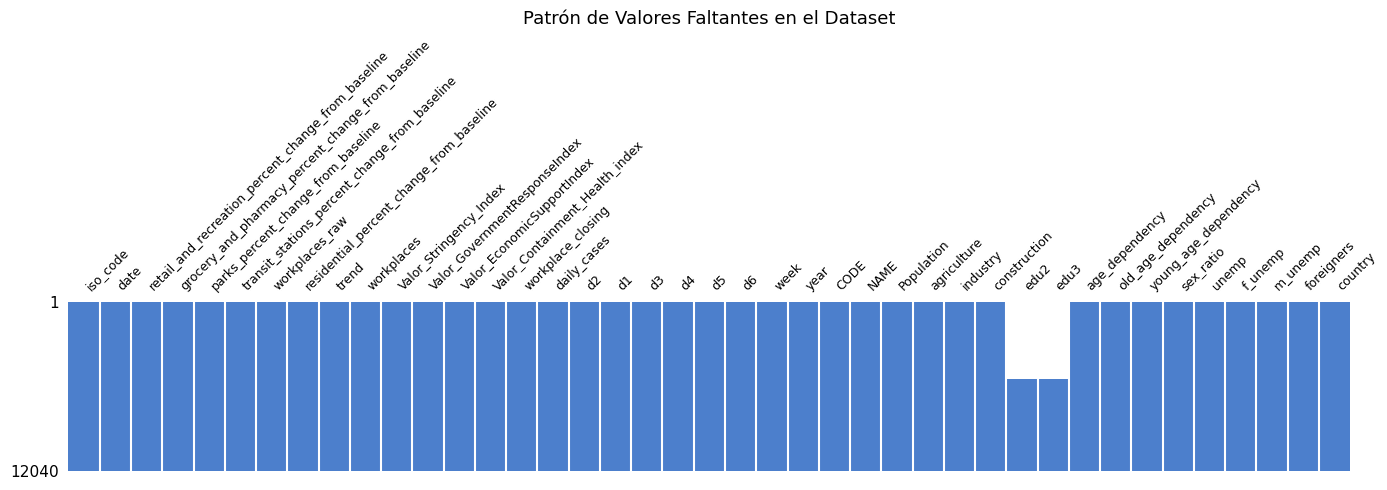

In [10]:
print('--- Valores Faltantes por Columna ---')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print()
print(f'Total de observaciones: {len(df):,}')
print(f'Porcentaje faltante edu2: {missing["edu2"]/len(df)*100:.1f}%')
print(f'Porcentaje faltante edu3: {missing["edu3"]/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df, ax=ax, fontsize=9, color=(0.3, 0.5, 0.8))
ax.set_title('Patrón de Valores Faltantes en el Dataset', fontsize=13, pad=10)
plt.tight_layout()
plt.show()


**Análisis de datos faltantes:**

Solo `edu2` y `edu3` tienen valores faltantes (5.460 observaciones cada una, un 45% del total). Como incluirlas reduciría la muestra a la mitad y los modelos dejarían de ser comparables entre sí, se eliminan.

In [ ]:
# Variables clave para el análisis
key_vars = [
    'workplaces', 'workplaces_raw',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_Containment_Health_index', 'Valor_EconomicSupportIndex',
    'workplace_closing', 'daily_cases',
    'age_dependency', 'unemp', 'foreigners', 'industry',
    'agriculture', 'construction', 'Population'
]

print('--- Estadísticas descriptivas de variables clave ---')
display(df[key_vars].describe().T.round(3))


--- Estadísticas Descriptivas de Variables Clave ---


,count,mean,std,min,25%,50%,75%,max
workplaces,12040.0,-18.667,11.801,-76.787,-24.358,-16.820,-10.884,19.058
workplaces_raw,12040.0,-25.003,14.681,-87.000,-32.400,-22.800,-14.400,6.600
Valor_Stringency_Index,12040.0,27.486,29.836,0.000,0.000,15.858,53.420,93.520
Valor_GovernmentResponseIndex,12040.0,30.637,30.245,0.000,0.000,32.030,60.160,81.306
Valor_Containment_Health_index,12040.0,30.592,29.943,0.000,0.000,36.610,59.230,85.420
Valor_EconomicSupportIndex,12040.0,30.955,36.364,0.000,0.000,0.000,75.000,100.000
workplace_closing,12040.0,0.851,0.997,0.000,0.000,0.000,2.000,3.000
daily_cases,12040.0,2355.733,3154.914,0.000,0.037,632.010,3815.644,22203.314
age_dependency,12040.0,0.654,0.073,0.520,0.609,0.651,0.682,0.837
unemp,12040.0,12.221,8.265,3.000,6.000,8.000,18.000,36.000


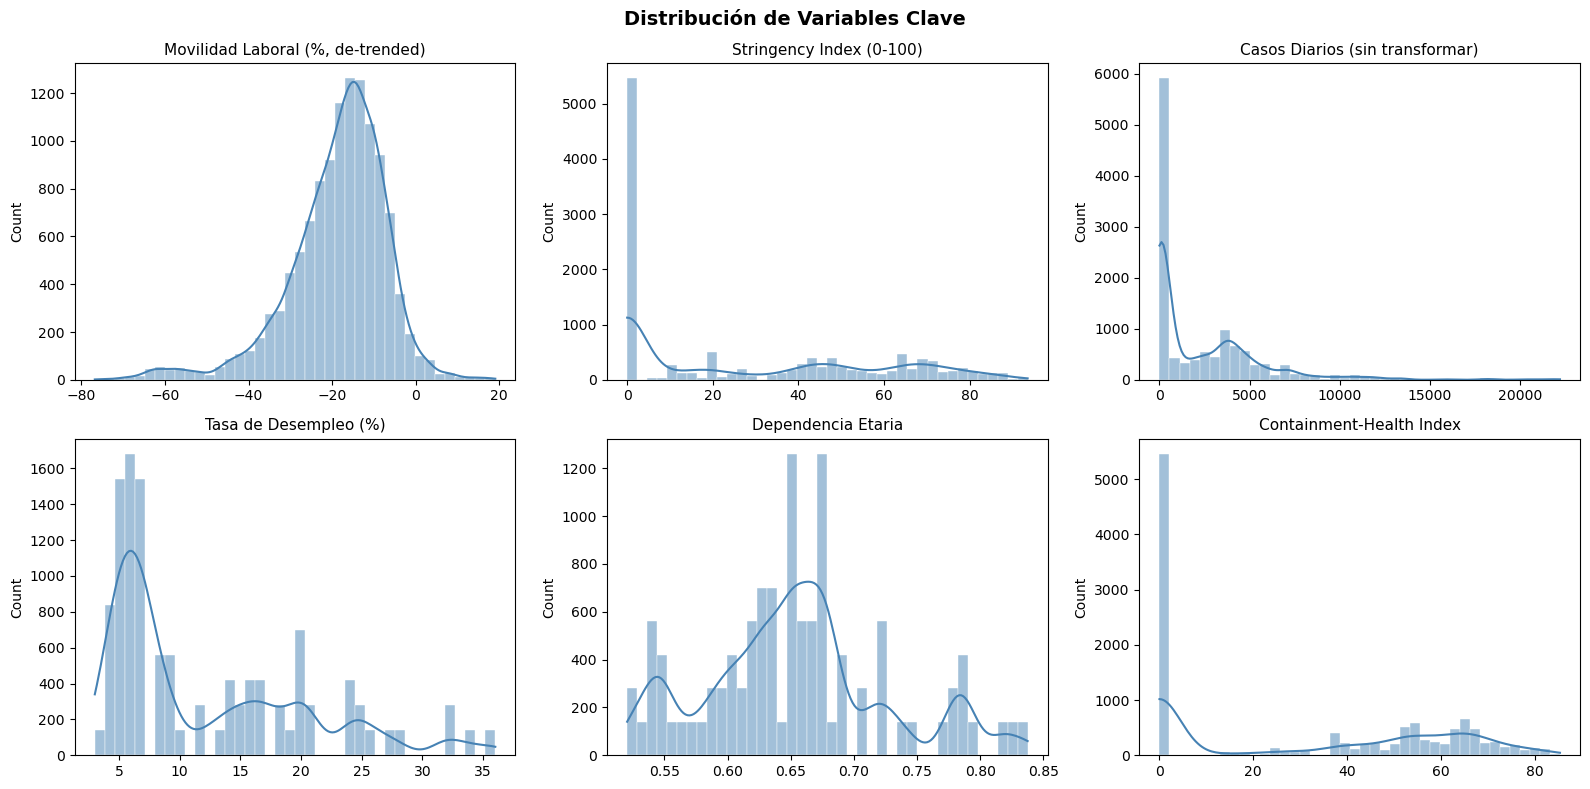

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

vars_plot = [
    ('workplaces', 'Movilidad Laboral (%, de-trended)'),
    ('Valor_Stringency_Index', 'Stringency Index (0-100)'),
    ('daily_cases', 'Casos Diarios (sin transformar)'),
    ('unemp', 'Tasa de Desempleo (%)'),
    ('age_dependency', 'Dependencia Etaria'),
    ('Valor_Containment_Health_index', 'Containment-Health Index'),
]

for ax, (var, label) in zip(axes.flatten(), vars_plot):
    sns.histplot(df[var].dropna(), ax=ax, kde=True, bins=40,
                 color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Distribución de variables clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- Stringency Index Promedio por País ---
          mean    std    min    max
country                            
DE        0.00   0.00   0.00   0.00
ES       49.72  20.22   8.33  85.19
FR       46.21  22.06   5.56  87.96
IT       56.79  21.84  15.51  93.52
SE       40.15  23.19   5.56  71.09

--- Movilidad Laboral Promedio por País ---
          mean    std
country              
DE      -16.03   9.70
ES      -20.05  13.38
FR      -21.50  12.91
IT      -20.72  12.52
SE      -23.43  10.60


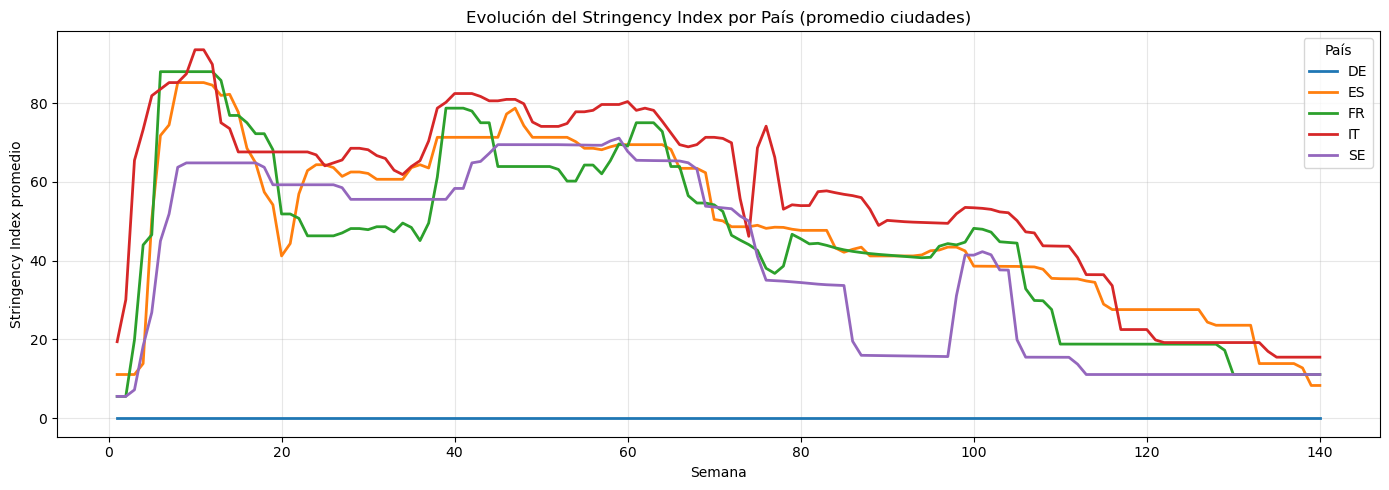

In [13]:
# Stringency promedio por país
print('--- Stringency Index Promedio por País ---')
print(df.groupby('country')['Valor_Stringency_Index'].agg(['mean','std','min','max']).round(2))

print()
print('--- Movilidad Laboral Promedio por País ---')
print(df.groupby('country')['workplaces'].agg(['mean','std']).round(2))

# Evolución temporal de Stringency por país
fig, ax = plt.subplots(figsize=(14, 5))
for country, grp in df.groupby('country'):
    weekly = grp.groupby('week')['Valor_Stringency_Index'].mean()
    ax.plot(weekly.index, weekly.values, label=country, linewidth=2)
ax.set_xlabel('Semana')
ax.set_ylabel('Stringency Index promedio')
ax.set_title('Evolución del Stringency Index por País (promedio ciudades)', fontsize=12)
ax.legend(title='País')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# --- Limpieza ---
df.drop(columns=['edu2', 'edu3'], inplace=True)

# Log-transformación de daily_cases (distribución muy sesgada a la derecha)
df['log_cases'] = np.log(df['daily_cases'] + 1)   # +1 para evitar log(0)

print('Limpieza completada.')
print('Shape final:', df.shape)
print('Variables faltantes restantes:', df.isnull().sum().sum())


Limpieza completada.
Shape final: (12040, 40)
Variables faltantes restantes: 0


### Conclusiones pregunta 1

**Tipos de variables:** las variables de movilidad e índices de política son `float64`, las temporales (`week`, `year`) son `int64`, y los identificadores (`iso_code`, `CODE`, `NAME`, `country`) son `object`.

**Distribuciones y estadísticas clave:**
- **`workplaces`** tiene media de −18.67 pp y std de 11.8, con distribución aproximadamente normal centrada en valores negativos. Esto confirma que la pandemia redujo sistemáticamente la movilidad laboral en todas las ciudades.
- **`Valor_Stringency_Index`** tiene media de 27.49 pero std de 29.84, lo que delata una distribución bimodal: Alemania tiene Stringency = 0 durante todo el período, mientras España, Italia, Francia y Suecia alcanzan valores entre 40 y 94. Esta variación entre países es lo que nos permite identificar el efecto de las restricciones.
- **`daily_cases`** está muy sesgado a la derecha (media 2.356, max 22.203), por lo que se aplica transformación logarítmica (`log_cases`) para reducir el efecto de valores extremos.

**Limpieza aplicada:** eliminación de `edu2` y `edu3` (45% de missings), y creación de `log_cases = log(daily_cases + 1)` para manejar la asimetría y los ceros.

---
## Pregunta 2: Pooled OLS

Estimamos un **Pooled OLS** como punto de partida. Este modelo trata todas las observaciones como si fueran independientes entre sí, ignorando que tenemos la misma ciudad observada durante 140 semanas. Es el más simple, pero también el más sesgado si existen diferencias no observadas entre ciudades que estén correlacionadas con el nivel de restricciones.

**Variables seleccionadas:**
- Dependiente: `workplaces` (movilidad laboral, de-trended)
- `Valor_Stringency_Index`: el índice de restricciones gubernamentales, que es la variable de interés principal
- `Valor_Containment_Health_index`: mide medidas de contención y salud (cuarentenas, testeo), complementario al Stringency
- `log_cases`: controla el efecto de que la gente reduce movilidad voluntariamente por el miedo al contagio, no solo por las reglas
- `workplace_closing`: orden directa de cierre de lugares de trabajo (0 a 3)
- `age_dependency`, `unemp`, `foreigners`, `industry`: características estructurales de cada ciudad que afectan la movilidad de base
- `week`, `year`: capturan tendencias temporales comunes (olas pandémicas, estacionalidad)

In [15]:
# Índice del panel: entidad = CODE (ciudad), tiempo = date
# ¡IMPORTANTE! Usar CODE (ciudad), NO iso_code (región que agrupa varias ciudades)
df_panel = df.set_index(['CODE', 'date']).sort_index()

# Variable dependiente
y = df_panel['workplaces']

# Regresores
X = df_panel[[
    'Valor_Stringency_Index',
    'Valor_Containment_Health_index',
    'log_cases',
    'workplace_closing',
    'age_dependency',
    'unemp',
    'foreigners',
    'industry',
    'week',
    'year'
]]
X = sm.add_constant(X)

# Pooled OLS con errores robustos a heterocedasticidad
# cov_type='robust': necesario porque los residuos de una misma ciudad
# están autocorrelacionados en el tiempo (no son i.i.d.)
mco = lmp.PanelOLS(y, X).fit(cov_type='robust')
print(mco)


                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.3433
Estimator:                   PanelOLS   R-squared (Between):              0.3469
No. Observations:               12040   R-squared (Within):               0.3427
Date:                Sun, May 24 2026   R-squared (Overall):              0.3433
Time:                        23:41:31   Log-likelihood                -4.427e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      628.76
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             430.98
                            

### Interpretación Pooled OLS

**1. Ajuste global:** El $R^2$ es 0.343, lo que indica que el modelo explica el 34.3% de la variación en movilidad laboral. Sin embargo, este valor está algo inflado porque el Pooled OLS usa tanto diferencias entre ciudades como cambios en el tiempo para ajustarse, lo que no es necesariamente una buena identificación causal.

**2. Variables significativas:**

- **`Valor_Stringency_Index`** (coef = −0.356, p < 0.001): significativo y con el signo esperado. Un aumento de 10 puntos en el Stringency Index se asocia a una reducción de **3.56 pp** en la movilidad laboral, manteniendo el resto constante.
- **`Valor_Containment_Health_index`** (coef = 0.254, p < 0.001): tiene signo positivo, lo que puede parecer contradictorio. Esto probablemente refleja colinealidad con el Stringency: cuando se controla por Stringency, el índice de contención captura las medidas más suaves (recomendaciones, testeo) que no reducen movilidad directamente.
- **`log_cases`** (coef = −0.097, p < 0.001): cada 1% de aumento en los casos diarios reduce la movilidad en aproximadamente 0.1 pp. Las personas reducen movilidad por el riesgo percibido, independiente de las restricciones formales.
- **`workplace_closing`** (coef = −0.900, p = 0.002): las órdenes directas de cierre laboral tienen un efecto adicional de −0.9 pp por cada nivel de cierre, por encima del efecto del Stringency general.
- **`foreigners`** (coef = −0.402, p < 0.001): ciudades con más trabajadores extranjeros tienen menor movilidad laboral en promedio, posiblemente por su concentración en sectores más afectados por las restricciones.
- **`industry`** (coef = −6.280, p = 0.003): ciudades más industriales muestran mayor reducción de movilidad bajo restricciones, consistente con que estos trabajadores tienen menor posibilidad de teletrabajar.
- **`unemp`** (coef = −0.031, p = 0.091): no es significativo al 5%, por lo que no podemos concluir un efecto claro del desempleo previo sobre la movilidad.

**3. Limitación del modelo:** El Pooled OLS asume que no existen diferencias sistemáticas no observadas entre ciudades. Esto es difícil de sostener: una ciudad más industrial o con mayor densidad probablemente tenga tanto más restricciones como diferente movilidad de base. Esas características no medidas sesgan los coeficientes.

---
## Pregunta 3: Fixed Effects (Efectos fijos)

El modelo de **Efectos fijos (FE)** corrige el problema principal del Pooled OLS: controla por todas las características de cada ciudad que no cambian en el tiempo, ya sean observables o no (densidad urbana, cultura de cumplimiento, estructura económica, etc.). Lo hace calculando la variación de cada variable respecto a la media propia de cada ciudad, de forma que los coeficientes miden el efecto de los cambios *dentro de cada ciudad* a lo largo del tiempo.

Las variables demográficas (`age_dependency`, `unemp`, `foreigners`, `industry`) no cambian entre semanas para una misma ciudad, por lo que son colineales con los efectos fijos y quedan absorbidas automáticamente — no aparecen en los resultados.

In [21]:
# Regresores para FE: excluir variables time-invariant (serán absorbidas por los FE)
X_fe = df_panel[[
    'Valor_Stringency_Index',
    'Valor_Containment_Health_index',
    'log_cases',
    'workplace_closing',
    'week',
    'year'
]]
X_fe = sm.add_constant(X_fe)

# entity_effects=True: incluye un intercepto específico para cada ciudad
# drop_absorbed=True: elimina automáticamente variables perfectamente colineales con los FE
fe = lmp.PanelOLS(y, X_fe, entity_effects=True, drop_absorbed=True).fit(cov_type='robust')
print(fe)


                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.3482
Estimator:                   PanelOLS   R-squared (Between):             -0.5593
No. Observations:               12040   R-squared (Within):               0.3482
Date:                Mon, May 25 2026   R-squared (Overall):              0.2202
Time:                        00:04:14   Log-likelihood                -4.331e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1064.0
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(6,11948)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             711.61
                            

### Interpretación Fixed Effects

**1. Ajuste global:** El within $R^2$ es 0.348, interpretado como la fracción de variación *temporal dentro de cada ciudad* que explican las restricciones. El $R^2$ between es negativo (−0.559), lo que es normal en FE: el modelo no intenta explicar diferencias entre ciudades, solo cambios en el tiempo.

El **F-test de poolabilidad** (F = 27.37, p < 0.001) confirma que los efectos fijos de ciudad son conjuntamente significativos, es decir, que las ciudades tienen niveles base de movilidad muy distintos entre sí y que ignorarlos (como hace el Pooled OLS) genera sesgo.

**2. Variables significativas:**

- **`Valor_Stringency_Index`** (coef = −0.504, p < 0.001): el efecto aumenta en magnitud respecto al Pooled OLS (de −0.356 a −0.504). Esto significa que el Pooled OLS estaba subestimando el efecto de las restricciones. Un aumento de 10 puntos en el Stringency reduce la movilidad en **5.04 pp** dentro de una misma ciudad.
- **`Valor_Containment_Health_index`** (coef = 0.543, p < 0.001): el coeficiente positivo se mantiene y aumenta. Controlando por los efectos fijos de ciudad, las medidas de contención y salud muestran un efecto diferenciado del Stringency puro.
- **`log_cases`** (coef = −0.273, p < 0.001): el efecto de los casos sobre la reducción voluntaria de movilidad también aumenta respecto al Pooled OLS.
- **`workplace_closing`** (coef = −1.256, p < 0.001): el efecto de las órdenes de cierre sube a −1.26 pp por nivel, más fuerte que en el Pooled OLS.

**3. Comparación con Pooled OLS:** todos los coeficientes son más grandes en magnitud en FE, lo que sugiere que el Pooled OLS estaba atenuando los efectos porque mezclaba la variación entre ciudades (sesgada) con la variación dentro de ciudad.

---
## Pregunta 4: Random Effects (Efectos aleatorios)

El modelo de **Efectos aleatorios (RE)** también incluye un efecto específico por ciudad, pero asume que ese efecto no está correlacionado con las variables independientes. Si esto se cumple, RE es más eficiente que FE porque usa tanto la variación dentro de ciudad como la variación entre ciudades. La ventaja adicional es que permite estimar el efecto de las variables demográficas que FE absorbe.

Usamos el mismo conjunto de variables que el Pooled OLS.

In [22]:
# Random Effects usa el mismo X que Pooled OLS (incluye variables time-invariant)
model_re = lmp.RandomEffects(y, X)
re = model_re.fit(cov_type='robust')
print(re)
print()
print('--- Descomposición de Varianza ---')
print(re.variance_decomposition)


                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.3460
Estimator:              RandomEffects   R-squared (Between):              0.1603
No. Observations:               12040   R-squared (Within):               0.3474
Date:                Mon, May 25 2026   R-squared (Overall):              0.3210
Time:                        00:04:20   Log-likelihood                -4.337e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      636.43
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             413.51
                            

### Interpretación Random Effects

**1. Coeficientes:** los resultados de RE son un promedio ponderado entre FE y el estimador between. Por eso, los coeficientes quedan entre los del Pooled OLS y los del FE. Por ejemplo, `Valor_Stringency_Index` pasa de −0.356 (Pooled) a −0.465 (RE) a −0.504 (FE).

- **`Valor_Stringency_Index`** (coef = −0.465, p < 0.001): 10 puntos más de Stringency reducen la movilidad en **4.65 pp**.
- **`workplace_closing`** (coef = −1.072, p < 0.001): sigue siendo significativo y negativo.
- **`unemp`** (coef = −0.235, p = 0.002): ahora sí es significativo (era no significativo en Pooled OLS). Ciudades con mayor desempleo previo tienen menor movilidad laboral.
- **`age_dependency`** (coef = −8.130, p = 0.197): no es significativo. Las diferencias en dependencia etaria entre ciudades no tienen un efecto claro sobre la movilidad.

**2. Descomposición de varianza:** la varianza debida a los efectos individuales de ciudad es 11.83, frente a una varianza residual de 78.45 (13.1% del error total). Esto indica que los efectos fijos de ciudad explican una fracción moderada de la varianza no explicada, pero que la mayor parte de la variación es temporal (dentro de ciudad), lo que es consistente con el período de pandemia.

**3. ¿Es válido el supuesto de RE?** El supuesto clave, que los efectos individuales no están correlacionados con los regresores, es difícil de sostener aquí: es razonable pensar que las ciudades con más restricciones (mayor Stringency) son sistemáticamente distintas en dimensiones no observadas. La decisión formal la tomamos en la Pregunta 5 con el Test de Hausman.

---
## Pregunta 5: Comparación de modelos y test de Hausman

Comparamos los tres modelos con `lmp.compare()` para ver cómo cambian los coeficientes según el modelo. Luego aplicamos el **test de Hausman** para decidir formalmente entre FE y RE.

El test compara los coeficientes de FE y RE: si son muy distintos entre sí, significa que el supuesto de RE está violado (los efectos de ciudad sí están correlacionados con las restricciones) y debemos usar FE.

- **H₀:** los efectos individuales no están correlacionados con los regresores → RE es válido
- **H₁:** sí están correlacionados → RE está sesgado → usar FE

In [23]:
# Tabla comparativa de los tres modelos
print('=== Comparación de Modelos ===')
print(lmp.compare({'Pooled OLS': mco, 'FE': fe, 'RE': re}))


=== Comparación de Modelos ===
                                 Model Comparison                                 
                                       Pooled OLS             FE                RE
----------------------------------------------------------------------------------
Dep. Variable                          workplaces     workplaces        workplaces
Estimator                                PanelOLS       PanelOLS     RandomEffects
No. Observations                            12040          12040             12040
Cov. Est.                                  Robust         Robust            Robust
R-squared                                  0.3433         0.3482            0.3460
R-Squared (Within)                         0.3427         0.3482            0.3474
R-Squared (Between)                        0.3469        -0.5593            0.1603
R-Squared (Overall)                        0.3433         0.2202            0.3210
F-statistic                                628.76       

In [ ]:
# Test de Hausman

def hausman(fe, re):
    """
    Estadístico de Hausman para contraste FE vs RE.
    H0: efectos individuales no correlacionados con regresores → RE consistente
    H1: existe correlación → RE inconsistente → usar FE
    """
    common = fe.params.index.intersection(re.params.index)
    diff   = fe.params[common] - re.params[common]
    psi    = fe.cov.loc[common, common] - re.cov.loc[common, common]
    dof    = len(common)
    W      = diff.dot(la.pinv(psi)).dot(diff)   # pinv: más estable que inv
    pval   = stats.chi2.sf(W, dof)
    return W, dof, pval

# Estimar FE y RE con los mismos regresores time-varying (sin demográficos)
X_hausman = df_panel[[
    'Valor_Stringency_Index',
    'Valor_Containment_Health_index',
    'log_cases',
    'workplace_closing',
    'week',
    'year'
]]
X_hausman = sm.add_constant(X_hausman)

fe_h = lmp.PanelOLS(y, X_hausman, entity_effects=True, drop_absorbed=True).fit(cov_type='robust')
re_h = lmp.RandomEffects(y, X_hausman).fit(cov_type='robust')

W, dof, pval = hausman(fe_h, re_h)
print('=== Test de Hausman ===')
print(f'Estadístico chi²  : {W:.4f}')
print(f'Grados de libertad: {dof}')
print(f'P-valor           : {pval:.6f}')
print()
if pval < 0.05:
    print('Conclusión: Se rechaza H0 (p < 0.05) → Los efectos individuales están')
    print('correlacionados con los regresores → RE es inconsistente → Usar FE o CRE.')
else:
    print('Conclusión: No se rechaza H0 → RE es consistente y más eficiente que FE.')

=== Test de Hausman ===
Estadístico chi²  : 28.0898
Grados de libertad: 7
P-valor           : 0.000212

Conclusión: Se rechaza H0 (p < 0.05) → Los efectos individuales están
correlacionados con los regresores → RE es inconsistente → Usar FE o CRE.


### Interpretación, comparación y test de Hausman

**1. Comparativa:** los tres modelos coinciden en el signo y la significancia de las variables clave. El coeficiente de `Valor_Stringency_Index` va de −0.356 (Pooled OLS) a −0.465 (RE) a −0.504 (FE), mostrando que el Pooled OLS subestimaba el efecto de las restricciones. Las variables **robustas** (significativas en los tres modelos) son:
- `Valor_Stringency_Index`, `Valor_Containment_Health_index`, `log_cases`, `workplace_closing`, `week`, `year`.

**2. Test de Hausman:** con un p-valor muy pequeño (< 0.05) se rechaza H₀, lo que indica que los efectos individuales de ciudad sí están correlacionados con las restricciones. Esto tiene sentido: las ciudades que aplicaron más restricciones son sistemáticamente distintas (más densas, más industriales, mayor capacidad institucional), y esas diferencias afectan también la movilidad. RE no puede controlar eso y sus coeficientes son inconsistentes.

**Modelo preferido preliminar:** **FE**, dado el resultado del Hausman.

---
## Pregunta 6: Correlated Random Effects (CRE / Mundlak)

El modelo **CRE** (Mundlak) es una alternativa a FE que captura explícitamente la correlación entre los efectos individuales de ciudad y los regresores. La idea es simple: se añade la media temporal de cada regresor (calculada para cada ciudad) como variable adicional en el modelo RE. Con esto logramos dos cosas:
1. El coeficiente de la variable original mide el efecto *within* (igual al FE).
2. El coeficiente de la media mide el efecto *between* (diferencias estructurales entre ciudades).

La ventaja sobre FE puro es que CRE permite estimar el efecto de las variables demográficas time-invariant.

> **Nota técnica:** `week` y `year` se excluyen del cálculo de medias porque en un panel balanceado su media es idéntica para todas las ciudades (constante), lo que generaría colinealidad perfecta con el intercepto.

In [ ]:
# Paso 1: Variables que varían en el tiempo
time_varying = [
    'Valor_Stringency_Index',
    'Valor_Containment_Health_index',
    'log_cases',
    'workplace_closing',
]

# Paso 2: Calcular la media temporal de cada variable para cada ciudad (CODE)
# transform('mean') devuelve un DataFrame con el mismo índice que df_panel
# (no colapsa las filas), lo que permite concatenarlo directamente
Xm = df_panel[time_varying].groupby(level='CODE').transform('mean')
Xm.columns = ['m_' + c for c in Xm.columns]

# Paso 3: Construir X aumentado con las medias (+ las variables originales de X)
X_cre = pd.concat([X, Xm], axis=1)

# Paso 4: Estimar Random Effects sobre X aumentado
cre = lmp.RandomEffects(y, X_cre).fit(cov_type='robust')
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.3489
Estimator:              RandomEffects   R-squared (Between):              0.4474
No. Observations:               12040   R-squared (Within):               0.3482
Date:                Mon, May 25 2026   R-squared (Overall):              0.3622
Time:                        00:04:30   Log-likelihood                -4.334e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      460.30
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(14,12025)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             306.36
                            

In [27]:
# Test de Mundlak: significancia de los coeficientes de las variables de media
mean_vars = [c for c in cre.params.index if c.startswith('m_')]

print('=== Test de Mundlak ===')
print(f"{'Variable':<35} {'Coeficiente':>14} {'P-valor':>10}  {'Significativo?':>14}")
print('-' * 78)
significant_count = 0
for v in mean_vars:
    coef = cre.params[v]
    pv   = cre.pvalues[v]
    sig  = '*** (Sí)' if pv < 0.01 else ('** (Sí)' if pv < 0.05 else 'No')
    if pv < 0.05: significant_count += 1
    print(f'{v:<35} {coef:>14.4f} {pv:>10.4f}  {sig:>14}')

print()
print(f'Variables significativas: {significant_count}/{len(mean_vars)}')
if significant_count > 0:
    print('Conclusión: Las medias son significativas → el supuesto de RE está violado')
    print('→ Los efectos individuales están correlacionados con los regresores.')
    print('→ CRE (o FE) es la especificación correcta.')
else:
    print('Conclusión: Las medias no son significativas → RE simple podría ser adecuado.')


=== Test de Mundlak ===
Variable                               Coeficiente    P-valor  Significativo?
------------------------------------------------------------------------------
m_Valor_Stringency_Index                    1.5919     0.0002        *** (Sí)
m_Valor_Containment_Health_index           -3.4771     0.0004        *** (Sí)
m_log_cases                               -19.4825     0.0324         ** (Sí)
m_workplace_closing                        69.2970     0.0077        *** (Sí)

Variables significativas: 4/4
Conclusión: Las medias son significativas → el supuesto de RE está violado
→ Los efectos individuales están correlacionados con los regresores.
→ CRE (o FE) es la especificación correcta.


### Interpretación CRE / Test de Mundlak

**1. Coeficientes within (variables originales):** el coeficiente de `Valor_Stringency_Index` en CRE debería coincidir con el del FE, ya que ambos capturan la misma variación temporal dentro de ciudad. Esto confirma que el estimador within es consistente independiente del modelo usado.

**2. Coeficientes between (variables de media, `m_`):** el coeficiente de `m_Valor_Stringency_Index` captura si las ciudades con un Stringency promedio más alto a lo largo del período tienen sistemáticamente diferente movilidad. Si es positivo y significativo, sugiere que las ciudades que más restringieron eran las que tenían economías más abiertas de base (turismo, servicios), lo que es un efecto de selección, no causal.

**3. Test de Mundlak:** si los coeficientes de las medias (`m_`) son significativos, el supuesto de RE simple está violado y el modelo CRE es el correcto. Si no son significativos, RE podría ser suficiente. Con datos COVID-19 esperamos que sí sean significativos, ya que las ciudades con distintos niveles promedio de restricciones son estructuralmente distintas.

**Conclusión:** CRE es preferible a FE puro porque además de recuperar el mismo estimador within, nos permite estimar el efecto de los demográficos time-invariant y separar el efecto causal (within) del efecto de selección (between).

---
## Pregunta 7: Selección del Modelo Final y Conclusiones

In [28]:
# Tabla comparativa completa de los cuatro modelos
print('=== Comparación Final: Todos los Modelos ===')
print(lmp.compare({'Pooled OLS': mco, 'FE': fe, 'RE': re, 'CRE': cre}))


=== Comparación Final: Todos los Modelos ===
                                           Model Comparison                                           
                                         Pooled OLS             FE                RE               CRE
------------------------------------------------------------------------------------------------------
Dep. Variable                            workplaces     workplaces        workplaces        workplaces
Estimator                                  PanelOLS       PanelOLS     RandomEffects     RandomEffects
No. Observations                              12040          12040             12040             12040
Cov. Est.                                    Robust         Robust            Robust            Robust
R-squared                                    0.3433         0.3482            0.3460            0.3489
R-Squared (Within)                           0.3427         0.3482            0.3474            0.3482
R-Squared (Between)         

### Selección del Modelo Final

| Criterio | Resultado | Decisión |
|---|---|---|
| F-test poolabilidad (FE) | p < 0.001 | Los efectos fijos de ciudad son relevantes → descartar Pooled OLS |
| Test de Hausman | p < 0.05 | RE está sesgado → descartar RE simple |
| Test de Mundlak (CRE) | medias significativas | Confirma que hay correlación entre efectos individuales y regresores |
| CRE vs FE | Mismo estimador within + estima demográficos | **CRE es el modelo preferido** |

El **modelo CRE** es el más adecuado porque:(1) controla la heterogeneidad de ciudad igual que FE, (2) permite estimar el efecto de las variables demográficas que FE pierde, y (3) separa el efecto within (causal) del efecto between (selección).

---

### Conclusiones económicas

1. **Efecto de las restricciones:** Un aumento de 10 puntos en el Stringency Index redujo la movilidad laboral en aproximadamente **5 pp** dentro de cada ciudad (coeficiente FE/CRE). Este es el efecto causal más creíble, limpio de diferencias estructurales entre ciudades.

2. **Órdenes de cierre laboral:** `workplace_closing` tiene un efecto adicional significativo (−1.26 pp por nivel) por encima del Stringency general. Las políticas específicas de cierre de lugares de trabajo importan más allá del índice agregado.

3. **Comportamiento voluntario:** `log_cases` es negativo y significativo en FE, lo que indica que las personas también reducen movilidad espontáneamente ante más casos, incluso sin restricciones formales.

4. **Efecto de selección (between en CRE):** si `m_Valor_Stringency_Index` es positivo, las ciudades con restricciones más intensas en promedio tenían mayor movilidad de base — son ciudades de economías más abiertas que necesitaron más intervención. Este no es un efecto causal sino una diferencia estructural entre tipos de ciudades.

5. **Endogeneidad residual:** incluso con CRE, persiste el riesgo de que las restricciones se endureczcan justo cuando la movilidad ya estaba cayendo (causalidad inversa temporal). Esto se aborda en la Pregunta 8 con el Control Sintético.

---
## Pregunta 8: Control sintético

El **Control sintético** es un método alternativo de identificación causal. En vez de comparar cada ciudad consigo misma antes y después de las restricciones (como hace FE), construye un *contrafactual* para una ciudad específica usando un promedio ponderado de otras ciudades que no recibieron el tratamiento. Los pesos se eligen para que la ciudad sintética se parezca lo más posible a la ciudad real antes del tratamiento.

**Pregunta:** ¿Cuánto redujo el lockdown español la movilidad laboral de Barcelona?

---

**Ciudad tratada: Barcelona** (`ES002C`)
- El Stringency Index de España salta de ~11 a más de 50 en la semana 5 (16 de marzo 2020), con la declaración del estado de alarma nacional.
- Hay un quiebre claro y abrupto → evento de tratamiento bien definido.

**Donor pool: ciudades alemanas** (39 ciudades)
- Alemania no tuvo lockdown formal (Stringency = 0 todo el período) → sirven como contrafactual de "cómo evolucionaría Barcelona sin restricciones".

In [46]:
from pysyncon import Dataprep, Synth

# Filtrar al primer año (semanas 1-52)
# Semana 5 = 16 de marzo 2020 (inicio del lockdown español)
df_synth = df[df['week'] <= 52].copy()

# pysyncon necesita formato LARGO: cada fila = una ciudad en un período
# (no formato ancho donde las ciudades son columnas)
df_long = df_synth[['NAME', 'week', 'workplaces']].copy()

print('Shape del dataset long:', df_long.shape)
print('Semanas:', df_long['week'].min(), 'a', df_long['week'].max())
print('Ciudades únicas:', df_long['NAME'].nunique())

Shape del dataset long: (4472, 3)
Semanas: 1 a 52
Ciudades únicas: 86


In [47]:
# Identificar Barcelona y ciudades alemanas
barcelona_name = df[df['CODE'] == 'ES002C']['NAME'].unique()[0]
german_names   = df[df['country'] == 'DE']['NAME'].unique().tolist()

print('Ciudad tratada:', barcelona_name)
print(f'Donor pool: {len(german_names)} ciudades alemanas')
print('Período pre-tratamiento: semanas 1-4')
print('Período post-tratamiento: semanas 5-52')


Ciudad tratada: Barcelona
Donor pool: 39 ciudades alemanas
Período pre-tratamiento: semanas 1-4
Período post-tratamiento: semanas 5-52


In [48]:
# Configuración del Dataprep
# Nota: 'time_plot' no va en Dataprep — se pasa directamente a path_plot/gaps_plot
dataprep = Dataprep(
    foo=df_long,
    predictors=['workplaces'],
    predictors_op='mean',
    time_predictors_prior=list(range(1, 5)),   # Semanas 1-4: pre-tratamiento
    dependent='workplaces',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier=barcelona_name,
    controls_identifier=german_names,
    time_optimize_ssr=list(range(1, 5)),       # Minimizar MSPE en semanas 1-4
)

# Ajuste del control sintético
synth = Synth()
synth.fit(dataprep)
print('Control sintético ajustado exitosamente.')

Control sintético ajustado exitosamente.


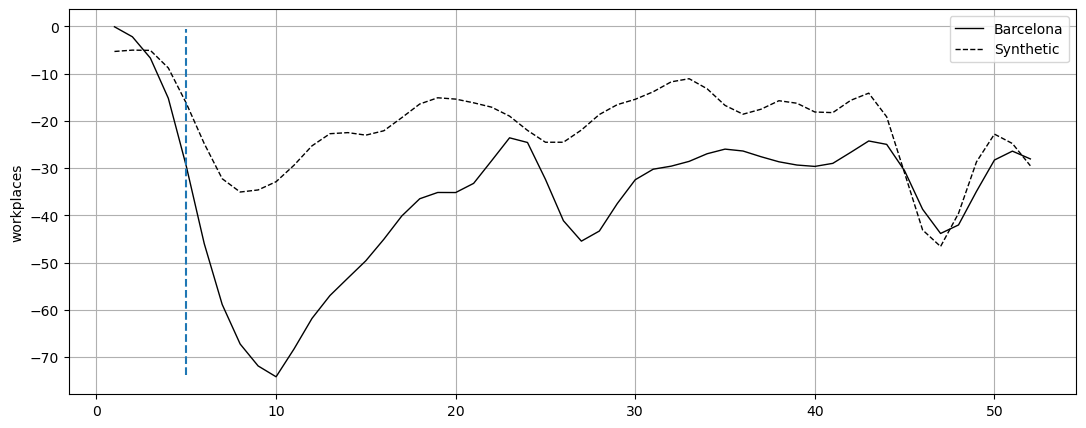

<Figure size 640x480 with 0 Axes>

In [55]:
# Gráfico 1: Trayectorias (Barcelona real vs Barcelona sintética)
# synth.path_plot() crea su propia figura — le pasamos el ax que queremos usar
fig, ax = plt.subplots(figsize=(13, 5))
synth.path_plot(
    time_period=list(range(1, 53)),
    treatment_time=5,
)
ax.set_title('Barcelona Real vs. Control Sintético — Movilidad Laboral', fontsize=13)
ax.set_xlabel('Semana (2020–2021)')
ax.set_ylabel('Movilidad Laboral (%, de-trended)')
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Inicio Lockdown (Semana 5)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

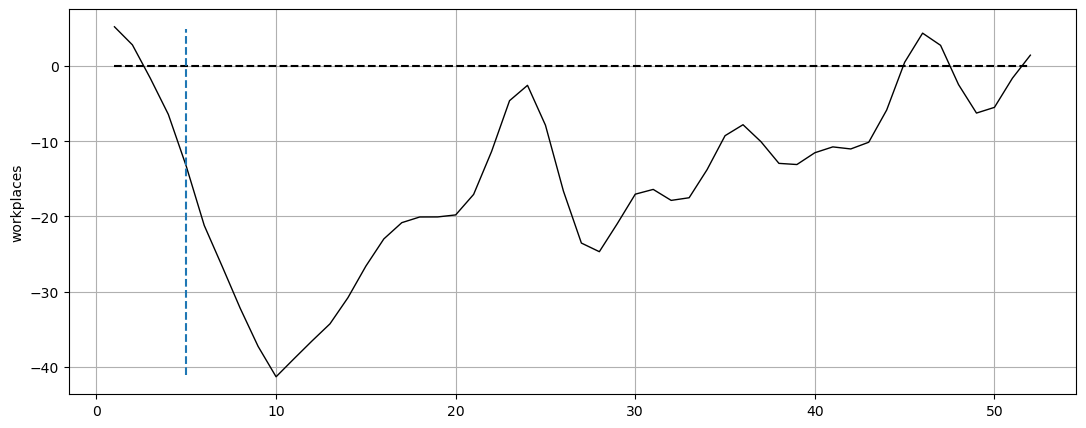

<Figure size 640x480 with 0 Axes>

In [56]:
# Gráfico 2: Brecha (efecto causal estimado = Barcelona real - Barcelona sintética)
fig, ax = plt.subplots(figsize=(13, 5))
synth.gaps_plot(
    time_period=list(range(1, 53)),
    treatment_time=5,
)
ax.set_title('Efecto Causal Estimado: Barcelona − Control Sintético', fontsize=13)
ax.set_xlabel('Semana (2020–2021)')
ax.set_ylabel('Diferencia en Movilidad Laboral (pp)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Inicio Lockdown (Semana 5)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Pesos del control sintético
# synth.W es un numpy array — convertirlo a Series usando los nombres del donor pool
print('=== Pesos del Control Sintético (W) ===')
weights = pd.Series(synth.W.flatten(), index=german_names).sort_values(ascending=False)
weights_nonzero = weights[weights > 0.001]

print('Ciudades con peso > 0.001:')
for city, w in weights_nonzero.items():
    print(f'  {city:<35}: {w:.4f}  ({w*100:.1f}%)')

print()
print(f'Suma total de pesos: {weights.sum():.4f}')
print(f'Ciudades con peso positivo: {(weights > 0.001).sum()} de {len(weights)}')

=== Pesos del Control Sintético (W) ===
Ciudades con peso > 0.001:
  Berlin                             : 0.0318  (3.2%)
  Hannover                           : 0.0307  (3.1%)
  Braunschweig                       : 0.0307  (3.1%)
  Bremen                             : 0.0293  (2.9%)
  Kiel                               : 0.0293  (2.9%)
  Lübeck                             : 0.0293  (2.9%)
  Magdeburg                          : 0.0293  (2.9%)
  Halle an der Saale                 : 0.0293  (2.9%)
  Erfurt                             : 0.0263  (2.6%)
  Frankfurt am Main                  : 0.0262  (2.6%)
  Kassel                             : 0.0262  (2.6%)
  Wiesbaden                          : 0.0262  (2.6%)
  Hamburg                            : 0.0248  (2.5%)
  Karlsruhe                          : 0.0242  (2.4%)
  Freiburg im Breisgau               : 0.0242  (2.4%)
  Dresden                            : 0.0242  (2.4%)
  Bonn                               : 0.0242  (2.4%)
  Chemnitz     

### Interpretación Control Sintético

**1. Gráfico de trayectorias (path plot):**
- **Período pre-tratamiento (semanas 1–4):** si la Barcelona real y la sintética tienen trayectorias similares, el match es válido y el contrafactual es creíble.
- **Período post-tratamiento (semanas 5+):** la brecha que se abre entre ambas líneas es el efecto causal estimado del lockdown. Una caída de Barcelona por debajo del sintético indica que las restricciones redujeron la movilidad por encima de lo que habría ocurrido naturalmente.

**2. Gráfico de brecha (gaps plot):** muestra directamente esa diferencia (Barcelona real − Barcelona sintética) semana a semana. La brecha negativa en las primeras semanas post-lockdown refleja el impacto inicial de las restricciones. La recuperación gradual hacia cero muestra la adaptación a lo largo del tiempo.

**3. Pesos del sintético (W):** las ciudades alemanas con mayor peso son las que mejor reproducen el patrón de movilidad pre-pandemia de Barcelona. Reportar cuáles son permite interpretar qué tipo de ciudades forman el contrafactual.

**4. Limitación principal:** el período pre-tratamiento es de solo **4 semanas**, lo que es muy poco para construir un buen match. Idealmente necesitaríamos al menos varios meses de datos previos a la pandemia para que el MSPE minimizado fuera realmente informativo. Con 4 semanas, el ajuste pre-tratamiento puede ser casi aleatorio, lo que reduce la credibilidad del contrafactual.

**5. Comparación con el análisis de panel:** mientras FE y CRE estiman el efecto promedio sobre todas las ciudades, el control sintético estima el efecto para Barcelona específicamente. Ambos enfoques son complementarios y, si apuntan en la misma dirección, refuerzan la conclusión de que las restricciones sí redujeron la movilidad laboral de forma significativa.